In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC,SVC
from sklearn.naive_bayes import MultinomialNB


## preprocess reduced data

### relabel data and enumerate words

In [3]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

In [2]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4

In [ ]:
dataset = pd.read_csv("../data_&_analysis/reduced.csv")

dataset["label"] = dataset["label"].map(mapped_dict)
# change words to numbers
dataset=dataset.dropna()

In [5]:
X_train,X_test,y_train,y_test = train_test_split(dataset["text"],dataset["label"],test_size=0.4,stratify=dataset["label"])
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test)


print("Size of training set: ", len(X_train))
print("Size of validation set: ", len(X_val))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = y_train.value_counts()
print(statistics)

print("Validation set classes distribution:")
statistics = y_val.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = y_test.value_counts()
print(statistics)

Size of training set:  13785
Size of validation set:  4595
Size of test set:  4595
Training set classes distribution: 
label
0    4478
1    4247
7    1618
3     883
4     642
6     539
5     493
2     490
8     240
9     155
Name: count, dtype: int64
Validation set classes distribution:
label
0    1492
1    1416
7     540
3     294
4     214
6     179
2     164
5     164
8      80
9      52
Name: count, dtype: int64
Test set classes distribution:
label
0    1493
1    1416
7     539
3     294
4     214
6     180
5     164
2     163
8      80
9      52
Name: count, dtype: int64


## vectorization

In [6]:
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

### tfidf

In [12]:
tfidf = TfidfVectorizer()
X_train_counts = tfidf.fit_transform(X_train)
X_test_counts = tfidf.transform(X_test)
X_val_counts = tfidf.transform(X_val)

# podejście OvR

Configuration: {'C': 0.1, 'max_iter': 1000, 'dual': True}, Validation Accuracy: 0.7612622415669206
Configuration: {'C': 1, 'max_iter': 1000, 'dual': True}, Validation Accuracy: 0.7612622415669206
Configuration: {'C': 10, 'max_iter': 2000, 'dual': True}, Validation Accuracy: 0.7612622415669206
Configuration: {'C': 0.5, 'max_iter': 2000, 'dual': True}, Validation Accuracy: 0.7612622415669206
Best Configuration: {'C': 0.1, 'max_iter': 1000, 'dual': True}, Best Validation Accuracy: 0.7612622415669206
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1493
           1       0.82      0.81      0.81      1416
           2       0.49      0.42      0.45       163
           3       0.49      0.60      0.54       294
           4       0.68      0.56      0.62       214
           5       0.48      0.49      0.48       164
           6       0.60      0.59      0.60       180
           7       0.73      0.76      0.75       539
           

<Axes: >

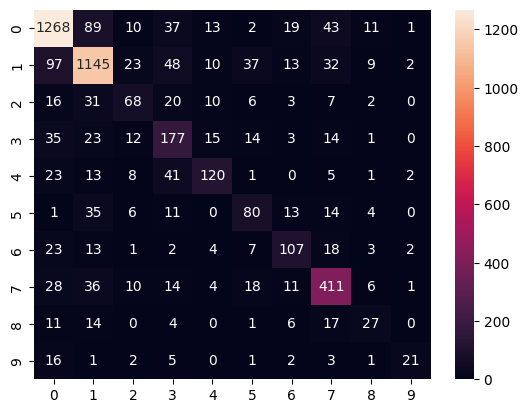

In [13]:
# create svm classifier for each label
classifiers = []
r_vectors=[]
configurations=[
    {"C": 0.1, "max_iter": 1000, "dual":True},
    {"C": 1, "max_iter": 1000, "dual":True},
    {"C": 10, "max_iter": 2000, "dual":True},
    {"C": 0.5, "max_iter": 2000, "dual":True}

]
best_config=None
best_score=0
for config in configurations:
    
    for i in range(class_number):
        
        bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
        bayes_clf.fit(X_train_counts, y_train == i)
        r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
        r_vectors.append(r)

        X_train_nbsvm = X_train_counts.multiply(r)

        # clf = SVC(kernel='rbf', C=1.0, tol=1e-2,verbose=True, class_weight='balanced', max_iter=2000)
        clf = LinearSVC(tol=1e-2, loss='squared_hinge', class_weight='balanced', **config)
        clf.fit(X_train_nbsvm, y_train == i)
        classifiers.append(clf)
    # evaluate each classifier on validation set
    all_scores=np.zeros((X_val_counts.shape[0], class_number))
    for i in range(class_number):
        r = r_vectors[i]
        X_val_nbsvm = X_val_counts.multiply(r)
        all_scores[:, i] = classifiers[i].decision_function(X_val_nbsvm)

    final_predictions = np.argmax(all_scores, axis=1)
    score = np.mean(final_predictions==y_val)
    print(f"Configuration: {config}, Validation Accuracy: {score}")

    if score > best_score:
            best_score = score
            best_configuration = config

print(f"Best Configuration: {best_configuration}, Best Validation Accuracy: {best_score}")

for i in range(class_number):
        
    bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
    bayes_clf.fit(X_train_counts, y_train == i)
    r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
    r_vectors.append(r)

    X_train_nbsvm = X_train_counts.multiply(r)

    # clf = SVC(kernel='rbf', C=1.0, tol=1e-2,verbose=True, class_weight='balanced', max_iter=2000)
    clf = LinearSVC(tol=1e-2, loss='squared_hinge', class_weight='balanced', **best_configuration)
    clf.fit(X_train_nbsvm, y_train == i)
    classifiers.append(clf)
# evaluate each classifier on validation set
all_scores=np.zeros((X_test_counts.shape[0], class_number))
for i in range(class_number):
    r = r_vectors[i]
    X_test_nbsvm = X_test_counts.multiply(r)
    all_scores[:, i] = classifiers[i].decision_function(X_test_nbsvm)

y_pred = np.argmax(all_scores, axis=1)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

# podejście OvO

Configuration: {'C': 0.1, 'max_iter': 1000, 'dual': True}, Validation Accuracy: 0.7312295973884657
Configuration: {'C': 1, 'max_iter': 1000, 'dual': True}, Validation Accuracy: 0.767791077257889
Configuration: {'C': 10, 'max_iter': 2000, 'dual': True}, Validation Accuracy: 0.761044613710555
Configuration: {'C': 0.5, 'max_iter': 2000, 'dual': True}, Validation Accuracy: 0.7619151251360174
Best Configuration: {'C': 1, 'max_iter': 1000, 'dual': True}, Best Validation Accuracy: 0.767791077257889
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1493
           1       0.74      0.86      0.80      1416
           2       0.70      0.39      0.50       163
           3       0.63      0.47      0.54       294
           4       0.74      0.52      0.61       214
           5       0.54      0.37      0.43       164
           6       0.76      0.54      0.63       180
           7       0.76      0.74      0.75       539
           8    

<Axes: >

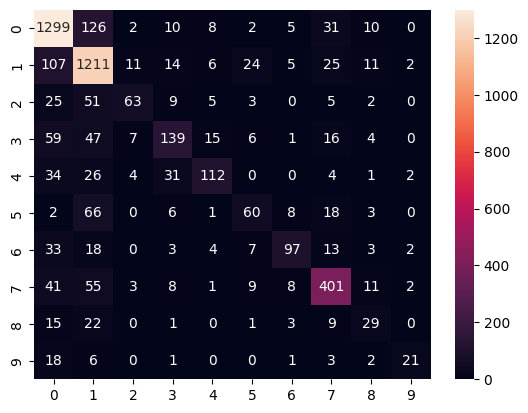

In [15]:
classifiers = {}
r_vectors={}
configurations=[
    {"C": 0.1, "max_iter": 1000, "dual":True},
    {"C": 1, "max_iter": 1000, "dual":True},
    {"C": 10, "max_iter": 2000, "dual":True},
    {"C": 0.5, "max_iter": 2000, "dual":True}

]
unique_classes = sorted(list(set(y_train.values)))
best_config=None
best_score=0
for config in configurations:
    
    for idx, i in enumerate(unique_classes):
        for j in unique_classes[idx + 1:]:
            
            mask = (y_train.values == i) | (y_train.values == j)
            
            X_train_pair = X_train_counts[mask]
            y_train_pair = (y_train.values[mask] == i).astype(int)
            
            # create weights using Naive Bayes
            bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
            bayes_clf.fit(X_train_pair, y_train_pair)
            r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
            r_vectors[(i,j)] = r
            
            
            X_train_nb = X_train_pair.multiply(r)
            
            clf = LinearSVC(tol=1e-2, loss='squared_hinge',class_weight='balanced',**config)
            clf.fit(X_train_nb, y_train_pair)
            classifiers[(i,j)] = clf

    confidence_scores=np.zeros((X_val_counts.shape[0], class_number))
    for (i,j), clf in classifiers.items():
        r = r_vectors[(i,j)]
        X_val_nbsvm = X_val_counts.multiply(r)
        score = clf.decision_function(X_val_nbsvm)
        confidence_scores[:, i] += score
        confidence_scores[:, j] -= score

    y_pred = np.argmax(confidence_scores, axis=1)
    score = np.mean(y_pred == y_val)
    print(f"Configuration: {config}, Validation Accuracy: {score}")
    if score > best_score:
        best_score = score
        best_configuration = config
print(f"Best Configuration: {best_configuration}, Best Validation Accuracy: {best_score}")

for idx, i in enumerate(unique_classes):
    for j in unique_classes[idx + 1:]:
        
        mask = (y_train.values == i) | (y_train.values == j)
        
        X_train_pair = X_train_counts[mask]
        y_train_pair = (y_train.values[mask] == i).astype(int)
        
        # create weights using Naive Bayes
        bayes_clf = MultinomialNB(alpha = 1.0, fit_prior=True)
        bayes_clf.fit(X_train_pair, y_train_pair)
        r = bayes_clf.feature_log_prob_[1]-bayes_clf.feature_log_prob_[0]
        r_vectors[(i,j)] = r
        
        
        X_train_nb = X_train_pair.multiply(r)
        
        clf = LinearSVC(tol=1e-2, loss='squared_hinge',class_weight='balanced', **config)
        clf.fit(X_train_nb, y_train_pair)
        classifiers[(i,j)] = clf

confidence_scores=np.zeros((X_test_counts.shape[0], class_number))
for (i,j), clf in classifiers.items():
    r = r_vectors[(i,j)]
    X_test_nbsvm = X_test_counts.multiply(r)
    score = clf.decision_function(X_test_nbsvm)
    confidence_scores[:, i] += score
    confidence_scores[:, j] -= score
y_pred = np.argmax(confidence_scores, axis=1)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')